<a href="https://colab.research.google.com/github/Anugraha-Prashanth/AI-ML-internship/blob/main/day3_Ai_walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

df




Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [2]:
from sklearn.preprocessing import LabelEncoder

encoded_data=df.copy()
label_encoder=LabelEncoder()
encoded_data['Date_Label']=label_encoder.fit_transform(encoded_data['Date'])



encoded_data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Date_Label
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,19
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106,52
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106,85
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106,118
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106,20
...,...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684,130
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667,22
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667,55
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667,88


In [3]:
df_new=df.drop(columns="Date")
encoded_new=encoded_data.drop(columns="Date")
encoded_new

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Date_Label
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,19
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,52
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,85
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,118
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,20
...,...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684,130
6431,45,733455.07,0,64.89,3.985,192.170412,8.667,22
6432,45,734464.36,0,54.47,4.000,192.327265,8.667,55
6433,45,718125.53,0,56.47,3.969,192.330854,8.667,88


In [4]:
df_new

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,718125.53,0,56.47,3.969,192.330854,8.667


<Axes: >

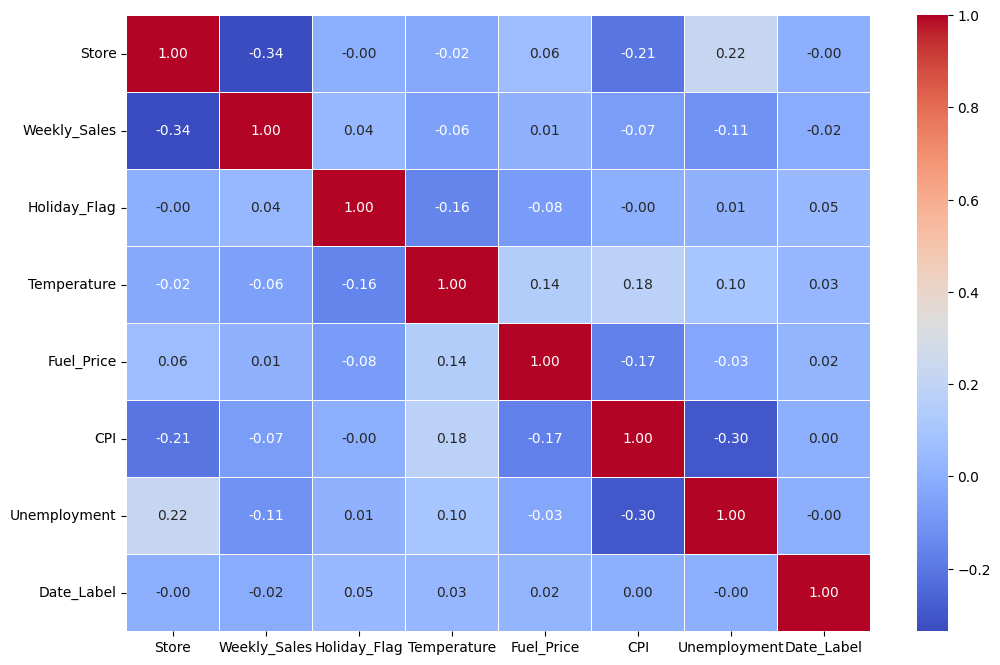

In [5]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(encoded_new.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [6]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler



numerical_col =["Store","Weekly_Sales","Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment"]

df_final = encoded_new.copy()

minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

df_final["Store"] = standard.fit_transform(df_final[["Store"]])
df_final["Weekly_Sales"] = standard.fit_transform(df_final[["Weekly_Sales"]])
df_final["Holiday_Flag"] = standard.fit_transform(df_final[["Holiday_Flag"]])
df_final["Temperature"] = standard.fit_transform(df_final[["Temperature"]])

df_final["Fuel_Price"] = standard.fit_transform(df_final[["Fuel_Price"]])
df_final["CPI"] = standard.fit_transform(df_final[["CPI"]])
df_final["Unemployment"] = standard.fit_transform(df_final[["Unemployment"]])
df_final["Date_Label"] = standard.fit_transform(df_final[["Date_Label"]])

df_final

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Date_Label
0,-1.693979,1.057420,-0.274204,-0.995136,-1.713800,1.004175,0.056964,-1.259704
1,-1.693979,1.054348,3.646917,-1.201170,-1.766089,1.007880,0.056964,-0.460277
2,-1.693979,1.001206,-0.274204,-1.124178,-1.840166,1.009074,0.056964,0.339151
3,-1.693979,0.642828,-0.274204,-0.760907,-1.737766,1.009849,0.056964,1.138579
4,-1.693979,0.899914,-0.274204,-0.767955,-1.598328,1.010624,0.056964,-1.235479
...,...,...,...,...,...,...,...,...
6430,1.693979,-0.591489,-0.274204,0.228602,1.390883,0.519270,0.365109,1.429280
6431,1.693979,-0.555551,-0.274204,0.229144,1.364738,0.523256,0.356046,-1.187029
6432,1.693979,-0.553762,-0.274204,-0.335825,1.397419,0.527241,0.356046,-0.387601
6433,1.693979,-0.582715,-0.274204,-0.227385,1.329879,0.527332,0.356046,0.411826


<Axes: >

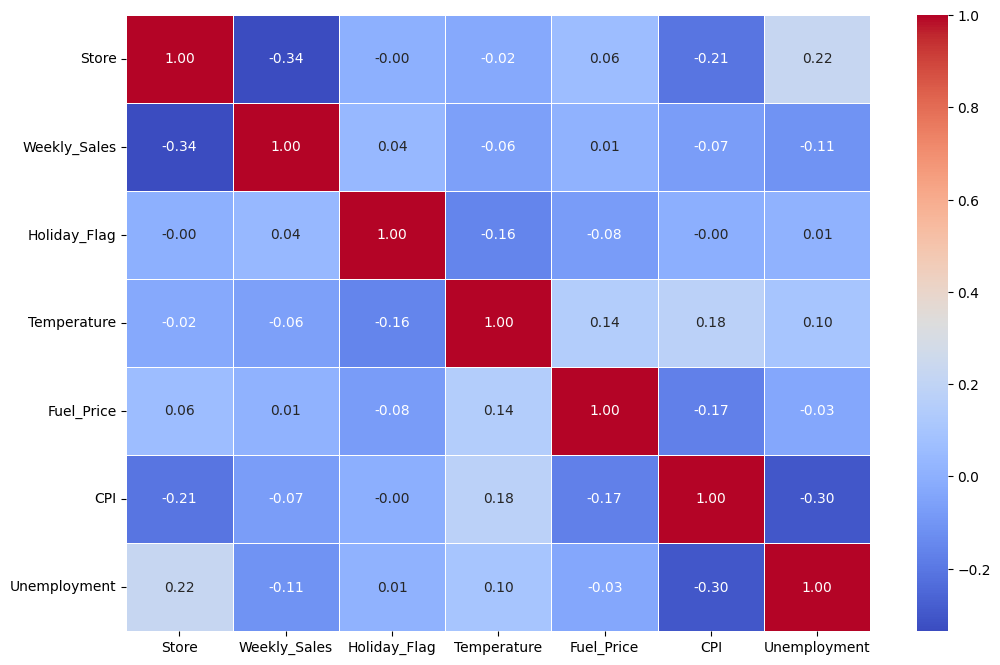

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_new.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [8]:
df_final.skew()

,0
Store,0.000000e+00
Weekly_Sales,6.683618e-01
Holiday_Flag,3.373499e+00
Temperature,-3.367676e-01
Fuel_Price,-9.615830e-02
CPI,6.349185e-02
Unemployment,1.188144e+00
Date_Label,-8.214287e-18


In [9]:
import numpy as np

# Find highly skewed columns
skewed_cols = df_final.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index
print("Highly Skewed Columns:\n", highly_skewed)
print("Negativly Skewed Columns:\n", negatively_skewed)


Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negativly Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Date_Label'],
      dtype='object')


In [10]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df_final[negatively_skewed] = pt.fit_transform(df_final[negatively_skewed])

In [11]:
df_final[highly_skewed]

,Holiday_Flag,Unemployment
0,-0.274204,0.056964
1,3.646917,0.056964
2,-0.274204,0.056964
3,-0.274204,0.056964
4,-0.274204,0.056964
...,...,...
6430,-0.274204,0.365109
6431,-0.274204,0.356046
6432,-0.274204,0.356046
6433,-0.274204,0.356046


In [12]:
df_final.skew()

,0
Store,-1.323143e-08
Weekly_Sales,1.006969e-01
Holiday_Flag,3.373499e+00
Temperature,-3.122440e-02
Fuel_Price,6.289478e-03
CPI,4.794927e-02
Unemployment,1.188144e+00
Date_Label,-1.063408e-09


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df_final.drop(columns=["Weekly_Sales"])  # All columns except target
y = df_final["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1369
RMSE: 0.9386


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f" Random Forest R² Score: {r2:.4f}")
print(f" Random Forest RMSE: {rmse:.4f}")

 Random Forest R² Score: 0.9614
 Random Forest RMSE: 0.1984
